In [1]:
# 실습 준비 - 패키지 설치
!pip install -q "numpy>=1.26" "pandas>=2.0" "matplotlib>=3.7" "statsmodels==0.14.6" "scikit-learn==1.8.0"

import os, json, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings; warnings.filterwarnings("ignore")

# 한글 폰트 — Colab 이면 나눔고딕을 설치한 뒤 그 ttf 를 폰트 목록에 **직접** 등록한다.
#  설치는 디스크에 파일만 만든다. 이미 떠 있는 폰트 목록은 그 사실을 모르므로 addfont 로
#  넣어 줘야 이름이 보인다(넣지 않으면 DejaVu Sans 로 밀려 한글이 전부 □ 로 나온다).
import glob, shutil, subprocess
if shutil.which("apt-get"):
    subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"], check=False)
for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):   # 설치 여부와 무관하게 한 번
    try: fm.fontManager.addfont(_p)
    except Exception: pass
try: fm._get_font.cache_clear()
except Exception: pass
installed = {f.name for f in fm.fontManager.ttflist}
FONT = next((n for n in ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"] if n in installed), "DejaVu Sans")
plt.rcParams["font.family"] = FONT
plt.rcParams["axes.unicode_minus"] = FONT in {"Pretendard", "DejaVu Sans"}   # 나머지 폰트에는 U+2212 가 없다
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}   # 그림마다 폭이 깎이지 않게
plt.rcParams["figure.dpi"] = plt.rcParams["savefig.dpi"] = 150       # 폭 FIG_W x 150dpi = 1500px 고정
plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 12,
                     "legend.fontsize": 11, "figure.titlesize": 17, "font.weight": "regular",
                     "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "axes.edgecolor": "#757575", "xtick.color": "#757575", "ytick.color": "#757575",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

# 오늘 그림 전체가 함께 쓰는 색 — 베이스라인=남색, 관측=파랑, 강조=하늘색, 문맥=회색
COL = {"남색": "#051C2C", "파랑": "#2251FF", "하늘색": "#00A9F4",
       "회색": "#757575", "연회색": "#B3B3B3"}
FIG_W = 10.0     # 캔버스 폭은 오늘 그림 모두 이 값으로 고정하고 높이만 그림마다 조절한다
SEED = 42        # 「오늘의 준비」 셀의 KFold(shuffle=True) 가 쓰는 시드 — 고정해야 표 2 의 숫자가 재현된다


def datefmt(ax, fmt="%m-%d", n=5):
    """시간 축 눈금 개수와 표기를 잡아 날짜 라벨이 겹치지 않게 한다"""
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=n))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))


def rmse(a, b):
    """평균 제곱근 오차 — 큰 오차가 제곱되어 더 크게 반영된다"""
    return float(np.sqrt(np.mean((np.asarray(a, dtype=float) - np.asarray(b, dtype=float)) ** 2)))


def mae(a, b):
    """평균 절대 오차 — 오차의 크기를 그대로 평균한다"""
    return float(np.mean(np.abs(np.asarray(a, dtype=float) - np.asarray(b, dtype=float))))


print("사용 폰트:", FONT, "| 색 팔레트 준비 완료 — 다음 셀이 오늘의 채점 셀을 올립니다")

사용 폰트: DejaVu Sans | 색 팔레트 준비 완료 — 다음 셀이 오늘의 채점 셀을 올립니다


In [2]:
font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["axes.unicode_minus"] = False

표 1 · 11월 16일 예측 원점 한 주의 RMSE (대)
  계절 나이브 168     205.25
  계절 나이브 24      271.23
  둘째 날 ARIMA     271.22
  셋째 날 SARIMA    386.08
  학습 구간 AIC 는 셋째 날 SARIMA 가 706.65 낮다
표 2 · 같은 5주를 채점한 선형회귀의 평균 RMSE (대)
  KFold(shuffle=True)              평균 RMSE  307.62   채점 시각보다 뒤인 학습 시각 평균  336시간
  TimeSeriesSplit(test_size=168)   평균 RMSE  335.67   채점 시각보다 뒤인 학습 시각 평균    0시간


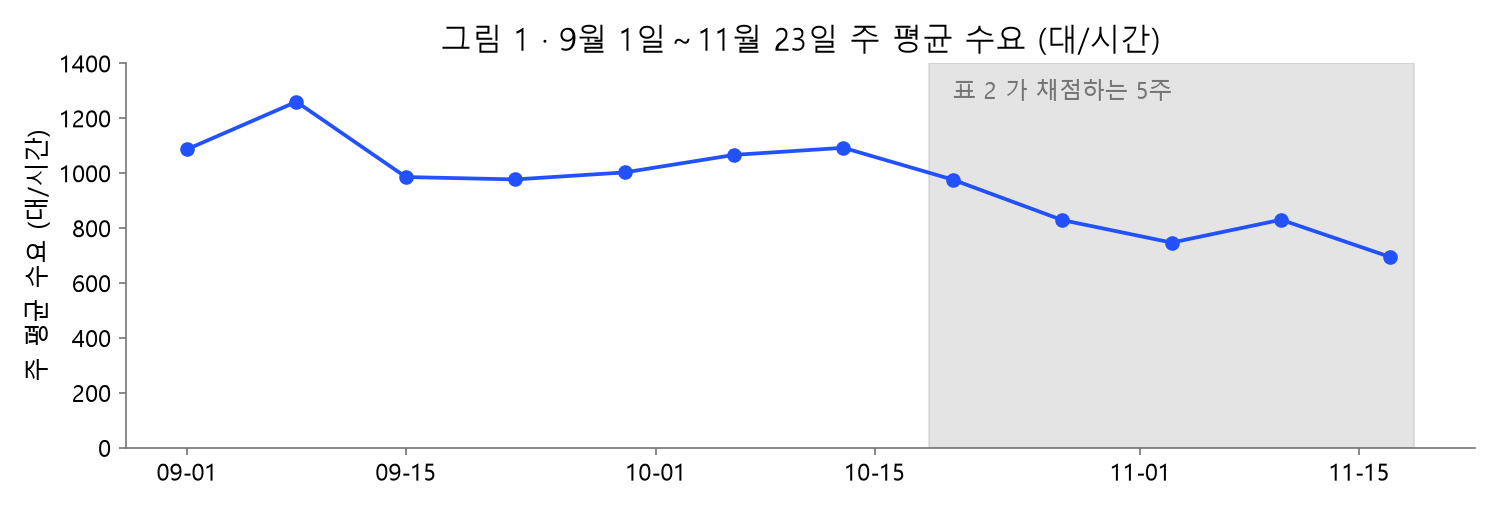

In [3]:
# 오늘의 준비 — 읽고 실행만 합니다
# 서울 공유자전거로 표 1 · 표 2 · 그림 1 을 만듭니다. 셋째 날 SARIMA 적합이 있어 30초 안팎 걸립니다
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, TimeSeriesSplit

URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
raw = pd.read_csv(URL, encoding="cp1252", compression="zip")        # 8,760행 x 14열
#  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 좌측 파일창에 올린 뒤
#  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요
raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",      # 위치 기반 리네임
               "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")    # 01/12/2017 = 2017년 12월 1일
                   + pd.to_timedelta(raw["hour"], unit="h"))
df = raw.sort_values("datetime").set_index("datetime")
df.index.freq = "h"                       # 등간격 1시간
_s = df["count"].astype(float).mask(df["functioning"].eq("No"))   # 휴무는 0 이 아니라 관측 없음
_y = _s.fillna(_s.shift(24 * 7))          # 1주일 전 같은 시각 값으로 채운다
df["demand"] = _y.fillna(_y.shift(-24 * 7))   # 1주일 전도 휴무인 시각만 1주일 뒤 값으로

# 표 1: 11월 16일 23시 예측 원점에서 168시간을 한 번에 예측한 후보 4개
train = df.loc["2018-09-01 00:00":"2018-11-16 23:00", "demand"]      # 학습 1,848시간
valid = df.loc["2018-11-17 00:00":"2018-11-23 23:00", "demand"]      # 검증 168시간
fits = {name: SARIMAX(train, order=(1, 0, 1), seasonal_order=so).fit(disp=False)
        for name, so in [("둘째 날 ARIMA", (0, 1, 0, 24)), ("셋째 날 SARIMA", (1, 1, 1, 24))]}
week_rmse = {"계절 나이브 168": rmse(valid, df["demand"].shift(168).loc[valid.index]),   # 1주일 전 같은 시각 값
             "계절 나이브 24": rmse(valid, np.tile(train.values[-24:], 7))}           # 11월 16일 하루를 7번
week_rmse.update({name: rmse(valid, res.forecast(168)) for name, res in fits.items()})
aic_gap = fits["둘째 날 ARIMA"].aic - fits["셋째 날 SARIMA"].aic   # 학습 구간의 1시간 뒤 예측으로 계산한 차이
print("표 1 · 11월 16일 예측 원점 한 주의 RMSE (대)")
for name, v in week_rmse.items():
    print(f"  {name:<12} {v:8.2f}")
print(f"  학습 구간 AIC 는 셋째 날 SARIMA 가 {aic_gap:,.2f} 낮다")

# 표 2: 같은 선형회귀를 분할기 두 개로 채점하고, 둘 다 마지막 5주(10월 20일～11월 23일)의 RMSE 를 평균
d_cv = df.loc["2018-09-01 00:00":"2018-11-23 23:00"]                 # 2,016시간
X_cv = pd.get_dummies(pd.DataFrame({"hour": d_cv.index.hour.astype(str),
                                    "dow": d_cv.index.dayofweek.astype(str)}, index=d_cv.index))
X_cv[["temp", "rain"]] = d_cv[["temp", "rain"]].values               # 시각 더미 24 · 요일 더미 7 · 기온 · 강수
X_cv, y_cv = X_cv.astype(float).values, d_cv["demand"].values
oof, n_later = np.zeros(len(y_cv)), np.zeros(len(y_cv))
for tr, te in KFold(5, shuffle=True, random_state=SEED).split(X_cv):   # 행 순서를 섞어 5개 폴드로
    oof[te] = LinearRegression().fit(X_cv[tr], y_cv[tr]).predict(X_cv[te])
    n_later[te] = [np.sum(tr > t) for t in te]                        # 채점 시각보다 뒤인데 학습에 들어간 시각 수
weeks = list(TimeSeriesSplit(n_splits=5, test_size=168).split(X_cv))  # 검증 폴드 = 마지막 5주
shuf_rmse = [rmse(y_cv[te], oof[te]) for _, te in weeks]
tss_rmse = [rmse(y_cv[te], LinearRegression().fit(X_cv[tr], y_cv[tr]).predict(X_cv[te])) for tr, te in weeks]
shuf_later = float(np.mean([n_later[te].mean() for _, te in weeks]))
tss_later = [int(np.sum(tr > te.min())) for tr, te in weeks]
print("표 2 · 같은 5주를 채점한 선형회귀의 평균 RMSE (대)")
print(f"  KFold(shuffle=True)              평균 RMSE {np.mean(shuf_rmse):7.2f}"
      f"   채점 시각보다 뒤인 학습 시각 평균 {shuf_later:4.0f}시간")
print(f"  TimeSeriesSplit(test_size=168)   평균 RMSE {np.mean(tss_rmse):7.2f}"
      f"   채점 시각보다 뒤인 학습 시각 평균 {np.mean(tss_later):4.0f}시간")

# 그림 1: 토요일～금요일 한 주씩 평균한 수요 12주, 회색 배경이 표 2 가 채점하는 5주
weekly = d_cv["demand"].resample("7D").mean()                         # 9월 1일(토)부터 7일씩
fig, ax = plt.subplots(figsize=(FIG_W, 3.4))
ax.plot(weekly.index, weekly.values, marker="o", color=COL["파랑"], lw=1.8)
ax.axvspan(pd.Timestamp("2018-10-18 12:00"), pd.Timestamp("2018-11-18 12:00"), color=COL["연회색"], alpha=0.35)
ax.text(pd.Timestamp("2018-10-20"), 1270, "표 2 가 채점하는 5주", color=COL["회색"])
ax.set_ylim(0, 1400)
ax.set_title("그림 1 · 9월 1일～11월 23일 주 평균 수요 (대/시간)")
ax.set_ylabel("주 평균 수요 (대/시간)")
datefmt(ax, n=7)
plt.show()

# 한 주 결과와 원점 5개 평균이 엇갈리면 무엇으로 정하나
예를 들어 모형 A 가 11월 16일 원점 한 주에서는 계절 나이브 168 보다 50대 크게 빗나갔고, 예측 원점 5개 평균에서는 20대 작게 빗나갔다고 합시다.

B. 원점 5개 평균이 베이스라인보다 작으니 투입을 논의하고, 원점 수와 학습 구간을 함께 적는다

투입 기준은 한 주의 값이 아니라 예측 원점 5개의 평균을 베이스라인과 비교하는 것입니다. 한 주의 순위는 그 주의 날씨와 요일 구성에 따라 반대가 되기도 합니다. 서울 공유자전거에서도 계절 나이브 168 의 한 주 RMSE 는 원점에 따라 크게 오르내립니다. 가장 최근 주만 따르는 첫 보기는 한 번의 운을 규칙으로 읽는 것입니다. 두 차이를 더하는 셋째 보기는 기준이 정해지지 않은 계산이라, 다른 사람이 다시 해도 같은 결론이 나온다는 보장이 없습니다. 그래서 원점 5개 평균으로 투입 논의를 시작합니다. 평가표에는 원점 5개·학습 구간·예측 기간 168시간을 적어 누가 다시 계산해도 같은 조건이 되게 합니다.

핵심 키워드: 원점 5개 평균이 기준, 한 주의 순위는 원점마다 달라진다, 평가표에 조건을 함께 적는다

# 교차 검증에서 스케일러는 어느 자료로 fit 하나
A. 분할마다 그 분할의 학습 폴드로 fit 한다

스케일러의 평균과 표준편차도 학습 자료에서 계산하는 값이라는 점이 열쇠입니다. 분할마다 예측 원점에서 이미 알던 값은 그 분할의 학습 폴드뿐입니다. 그래서 스케일러도 분할마다 학습 폴드로만 fit 하고, 평균과 표준편차가 분할마다 달라집니다. 전체 자료로 한 번 fit 하면 채점하는 주와 그 뒤의 값까지 평균에 들어갑니다. 검증 폴드를 합쳐 fit 하면 채점할 값의 평균을 미리 보는 셈입니다. 두 경우 모두 채점 시각보다 미래의 요약이 학습에 들어간 누수입니다. 코드로는 make_pipeline(StandardScaler(), 모형) 을 분할마다 학습 폴드로 fit 하면 스케일러가 학습 폴드 안에서만 계산됩니다.

핵심 키워드: 분할마다 학습 폴드로 fit, 요약 값도 누수가 된다, make_pipeline

# 한 주 채점표로 내릴 수 있는 판단
「오늘의 준비」 셀을 실행하면 나오는 「표 1 · 11월 16일 예측 원점 한 주의 RMSE (대)」를 봅니다. 이 표로 내릴 수 있는 판단은 무엇일까요?

C. 두 모형 모두 투입하지 않고, 원점을 옮겨 여러 주로 다시 채점한다

두 모형을 같은 주의 베이스라인과 나란히 읽는 것이 먼저입니다. 표 1 에서 계절 나이브 168 은 약 205대, 둘째 날 ARIMA 는 약 271대, 셋째 날 SARIMA 는 약 386대입니다. 두 모형 모두 1주일 전 값을 그대로 쓴 규칙보다 크게 빗나갔습니다. AIC 는 학습 구간의 1시간 뒤 예측으로 계산한 값이라, 168시간을 한 번에 내는 운영의 오차를 말해 주지 않습니다. 첫 보기는 이 차이를 놓친 읽기입니다. 둘째 보기는 한 주의 두 모형 순위만 보고 베이스라인을 빼먹은 읽기이고, 그 순위도 원점을 옮기면 반대가 될 수 있습니다. 이번 주에는 운영 예측을 계절 나이브 168 로 내고, 「11월 16일 원점 한 주에서 두 모형 모두 베이스라인보다 컸다」를 원점·구간과 함께 적어 둡니다. 순위는 예측 원점 5개로 다시 채점한 평균으로 정합니다.

핵심 키워드: 베이스라인과 같은 주에서 나란히, AIC 는 1시간 뒤 오차, 한 주로 순위를 정하지 않는다

# 더 작게 나온 교차 검증 RMSE 를 믿어도 되나
「오늘의 준비」 셀을 실행하면 나오는 「표 2 · 같은 5주를 채점한 선형회귀의 평균 RMSE (대)」를 봅니다. 두 분할기 가운데 평균 RMSE 가 더 작은 쪽을 교차 검증 결과로 보고해도 될까요?

B. 안 된다. 채점 시각보다 뒤의 시각을 학습에 포함한 값이라, 금요일 23시에는 할 수 없는 채점이다

더 작은 값이 어떤 조건에서 나왔는지부터 봅니다. 표 2 의 두 행은 같은 선형회귀로 같은 5주(10월 20일～11월 23일)를 채점했고, 다른 것은 분할기 하나입니다. KFold(shuffle=True) 행은 채점 시각보다 뒤인 시각이 평균 약 336시간 학습에 들어갔고, 그 행의 평균 RMSE 는 약 308대로 더 작습니다. 「그림 1 · 9월 1일～11월 23일 주 평균 수요 (대/시간)」에서 수요는 11월로 갈수록 줄어드는데, 행 순서를 무작위로 나누면 11월의 낮은 수요를 학습에서 미리 봅니다. 그래서 약 308대는 운영에서 받을 수 없는 값이고, 보고할 값은 TimeSeriesSplit 행의 약 336대입니다. 첫 보기는 학습에 무엇이 들어갔는지를 보지 않은 읽기입니다. 셋째 보기의 시드 고정은 같은 값을 다시 만들 뿐 값의 뜻을 바꾸지 않습니다. 시계열에서는 KFold(shuffle=True) 를 쓰지 않고, 보고서에는 값과 함께 분할기 이름과 검증 폴드 길이 168시간을 적습니다.

핵심 키워드: 채점 시각보다 뒤의 시각이 학습에 들어간 값, 운영에서 할 수 없는 채점, 분할기와 검증 폴드 길이를 함께 보고

In [4]:
# 미션 1 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 1 에 쓸 이름을 직접 만듭니다
URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
raw = pd.read_csv(URL, encoding="cp1252", compression="zip")        # 8,760행 x 14열
#  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 좌측 파일창에 올린 뒤
#  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요
raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",      # 위치 기반 리네임
               "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")    # 01/12/2017 = 2017년 12월 1일
                   + pd.to_timedelta(raw["hour"], unit="h"))
df = raw.sort_values("datetime").set_index("datetime")
df.index.freq = "h"                       # 등간격 1시간 — 시차 24 가 "24시간 전" 이라는 뜻이 된다
_s = df["count"].astype(float).mask(df["functioning"].eq("No"))   # 휴무는 0 이 아니라 관측 없음
_y = _s.fillna(_s.shift(24 * 7))          # 1주일 전 같은 시각 값으로 채운다 (요일 효과를 지키려고)
df["demand"] = _y.fillna(_y.shift(-24 * 7))   # 1주일 전도 휴무인 시각만 1주일 뒤 값으로

FIT_START = "2018-09-01 00:00"            # 학습 구간의 시작 — 예측 원점이 옮겨 가도 그대로 둔다
ORIGINS = pd.date_range("2018-10-19 23:00", "2018-11-16 23:00", freq="7D")   # 원점 5개, 모두 금요일 23시
ORDERS = {"둘째 날 ARIMA": (0, 1, 0, 24),                                     # 두 모형의 계절 차수
          "셋째 날 SARIMA": (1, 1, 1, 24)}


def fit_sarimax(y, seasonal_order):
    """차수 (1, 0, 1) 과 계절 차수로 적합합니다. 둘째 날·셋째 날과 같은 적합 조건"""
    return SARIMAX(y, order=(1, 0, 1), seasonal_order=seasonal_order, trend=None,
                   enforce_stationarity=True, enforce_invertibility=True).fit(disp=False)


print(f"행 x 열 : {df.shape[0]:,} x {df.shape[1]}   기간 {df.index.min()} ~ {df.index.max()}")
print("예측 원점 5개: 원점 뒤 168시간이 그 원점의 채점 구간입니다")
for _k, _o in enumerate(ORIGINS, 1):
    _n = len(df.loc[FIT_START:_o])
    print(f"  원점 {_k}  {_o:%m-%d(%a) %H시}   학습 {_n:,}시간"
          f"   채점 {_o + pd.Timedelta(hours=1):%m-%d %H시} ~ {_o + pd.Timedelta(hours=168):%m-%d %H시}")
print("쓸 수 있는 이름 : df (표 전체) · ORIGINS (예측 원점 5개) · FIT_START (학습 시작)"
      " · ORDERS (두 모형의 계절 차수) · fit_sarimax(y, seasonal_order) (적합 함수) · rmse(a, b)")

행 x 열 : 8,760 x 15   기간 2017-12-01 00:00:00 ~ 2018-11-30 23:00:00
예측 원점 5개: 원점 뒤 168시간이 그 원점의 채점 구간입니다
  원점 1  10-19(Fri) 23시   학습 1,176시간   채점 10-20 00시 ~ 10-26 23시
  원점 2  10-26(Fri) 23시   학습 1,344시간   채점 10-27 00시 ~ 11-02 23시
  원점 3  11-02(Fri) 23시   학습 1,512시간   채점 11-03 00시 ~ 11-09 23시
  원점 4  11-09(Fri) 23시   학습 1,680시간   채점 11-10 00시 ~ 11-16 23시
  원점 5  11-16(Fri) 23시   학습 1,848시간   채점 11-17 00시 ~ 11-23 23시
쓸 수 있는 이름 : df (표 전체) · ORIGINS (예측 원점 5개) · FIT_START (학습 시작) · ORDERS (두 모형의 계절 차수) · fit_sarimax(y, seasonal_order) (적합 함수) · rmse(a, b)


둘째 날 ARIMA 5주 평균 RMSE: 425.68대
셋째 날 SARIMA 5주 평균 RMSE: 385.06대
계절 나이브 168 5주 평균 RMSE: 363.55대
원점 1 (2018-10-19 23:00:00): 둘째 날 ARIMA=402.41, 셋째 날 SARIMA=345.39, 계절 나이브 168=306.52
원점 2 (2018-10-26 23:00:00): 둘째 날 ARIMA=545.20, 셋째 날 SARIMA=368.10, 계절 나이브 168=418.18
원점 3 (2018-11-02 23:00:00): 둘째 날 ARIMA=505.67, 셋째 날 SARIMA=508.05, 계절 나이브 168=457.07
원점 4 (2018-11-09 23:00:00): 둘째 날 ARIMA=403.92, 셋째 날 SARIMA=317.67, 계절 나이브 168=430.72
원점 5 (2018-11-16 23:00:00): 둘째 날 ARIMA=271.22, 셋째 날 SARIMA=386.08, 계절 나이브 168=205.25


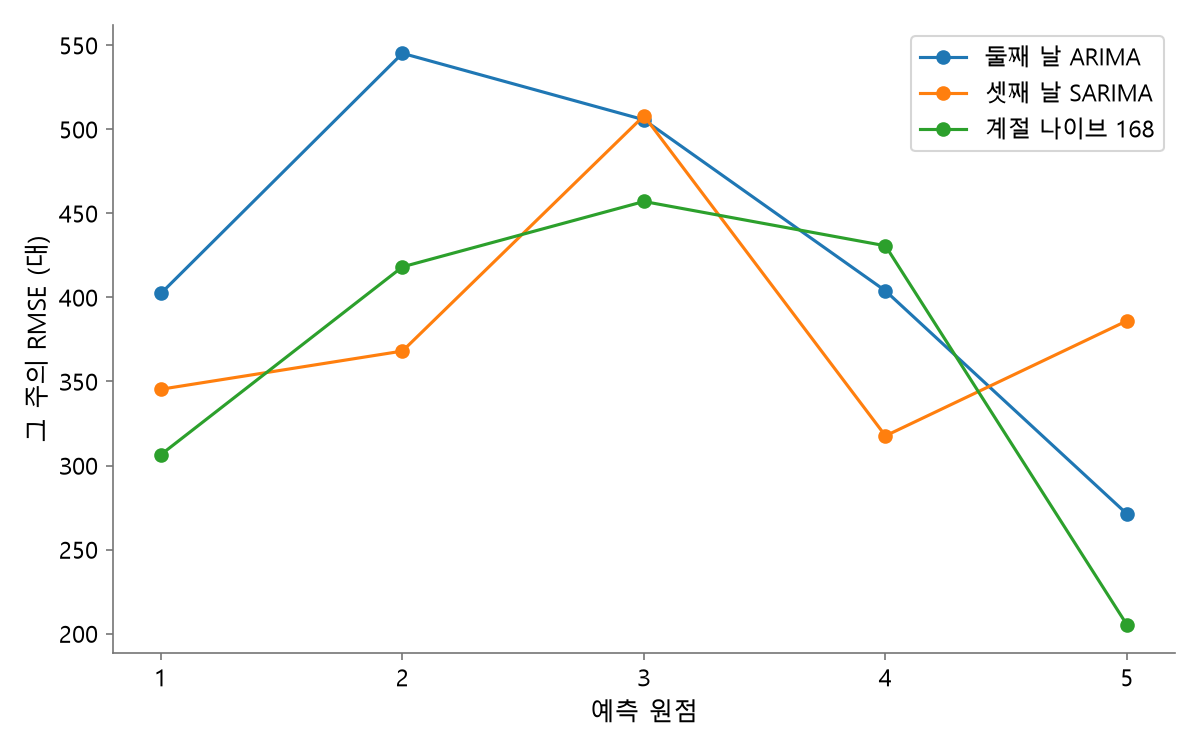

In [5]:
# 미션 1 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → AI 튜터에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
# 시킬 일은 AI 튜터 대화창이 아니라 아래 따옴표 안에 적습니다. 예시 프롬프트도 따옴표 안에 붙여 넣어야 채점됩니다
PROMPT = """
아래 출력물이 나오도록 코드 작성해줘
1. SARIMA 5주 평균 RMSE: 단위 '대', 소수 둘째자리
원점마다 9월 1일부터 원점까지로 다시 적합해 원점 뒤 168시간을 한번에 예측하고, RMSE 5개 평균함.
2. 계절 나이브 168 5주 평균 RMSE: 단위 '대', 소수 둘째자리
같은 원점, 같은 168시간에서 1주일 전 같은 시각 값을 예측으로 사용
3. 그래프
가로축: '예측 원점' 1~5
세로축: '그 주의 RMSE (대)'
선 3개(둘째 날 ARIMA · 셋째 날 SARIMA · 계절 나이브 168), 선마다 점 5개. 원점마다 세 값을 한 행씩 출력
"""
# --- 여기부터 AI 코드 ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

results = {name: [] for name in list(ORDERS.keys()) + ['계절 나이브 168']}

for origin in ORIGINS:
    train = df.loc[FIT_START:origin, 'demand']
    test_idx = pd.date_range(origin + pd.Timedelta(hours=1), periods=168, freq='h')
    y_true = df.loc[test_idx, 'demand']

    for name, seasonal_order in ORDERS.items():
        fitted = fit_sarimax(train, seasonal_order)
        y_pred = fitted.get_forecast(168).predicted_mean
        y_pred.index = test_idx
        rmse = np.sqrt(np.mean((y_true.values - y_pred.values) ** 2))
        results[name].append(rmse)

    naive_idx = test_idx - pd.Timedelta(hours=168)
    y_naive = df.loc[naive_idx, 'demand']
    rmse_naive = np.sqrt(np.mean((y_true.values - y_naive.values) ** 2))
    results['계절 나이브 168'].append(rmse_naive)

for name, rmses in results.items():
    print(f"{name} 5주 평균 RMSE: {np.mean(rmses):.2f}대")

for i, origin in enumerate(ORIGINS):
    row = [f"{name}={results[name][i]:.2f}" for name in results]
    print(f"원점 {i+1} ({origin}): " + ', '.join(row))

plt.figure(figsize=(8, 5))
for name, rmses in results.items():
    plt.plot(range(1, 6), rmses, marker='o', label=name)
plt.xlabel('예측 원점')
plt.ylabel('그 주의 RMSE (대)')
plt.xticks(range(1, 6))
plt.legend()
plt.show()

표 1 의 한 주에서는 둘째 날 ARIMA 가 셋째 날 SARIMA 보다 작게 빗나갔습니다. 원점 5개로 채점하면 어떻게 될까요?

2평균은 셋째 날 SARIMA 가 작지만, 두 모형 모두 계절 나이브 168 보다 크다

In [7]:
# 미션 2 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 2 에 쓸 이름을 직접 만듭니다
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
raw = pd.read_csv(URL, encoding="cp1252", compression="zip")        # 8,760행 x 14열
#  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 좌측 파일창에 올린 뒤
#  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요
raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",      # 위치 기반 리네임
               "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")    # 01/12/2017 = 2017년 12월 1일
                   + pd.to_timedelta(raw["hour"], unit="h"))
df = raw.sort_values("datetime").set_index("datetime")
df.index.freq = "h"                       # 등간격 1시간
_s = df["count"].astype(float).mask(df["functioning"].eq("No"))   # 휴무는 0 이 아니라 관측 없음
_y = _s.fillna(_s.shift(24 * 7))          # 1주일 전 같은 시각 값으로 채운다
df["demand"] = _y.fillna(_y.shift(-24 * 7))   # 1주일 전도 휴무인 시각만 1주일 뒤 값으로

d_cv = df.loc["2018-09-01 00:00":"2018-11-23 23:00"]                 # 교차 검증에 쓰는 2,016시간
_X = pd.get_dummies(pd.DataFrame({"hour": d_cv.index.hour.astype(str),
                                  "dow": d_cv.index.dayofweek.astype(str)}, index=d_cv.index))
_X["temp"] = d_cv["temp"].values          # 기온 (°C)
_X["rain"] = d_cv["rain"].values          # 강수 (mm)
TEMP_COL = list(_X.columns).index("temp")   # X_cv 에서 기온 열의 번호
X_cv = _X.astype(float).values            # 시각 더미 24 · 요일 더미 7 · 기온 · 강수 = 33열
y_cv = d_cv["demand"].values              # 보정 수요 (대)

print(f"교차 검증 구간 : {d_cv.index.min():%Y-%m-%d %H시} ~ {d_cv.index.max():%Y-%m-%d %H시}"
      f"   ({len(d_cv):,}시간)   설명 변수 {X_cv.shape[1]}열")
print(f"기온 열 번호 TEMP_COL : {TEMP_COL}   전체 2,016시간의 기온 평균 {X_cv[:, TEMP_COL].mean():.2f} °C")
print("쓸 수 있는 이름 : X_cv (설명 변수) · y_cv (보정 수요, 대) · TEMP_COL (기온 열 번호)"
      " · TimeSeriesSplit · make_pipeline · StandardScaler · Ridge · rmse(a, b)")

교차 검증 구간 : 2018-09-01 00시 ~ 2018-11-23 23시   (2,016시간)   설명 변수 33열
기온 열 번호 TEMP_COL : 31   전체 2,016시간의 기온 평균 14.92 °C
쓸 수 있는 이름 : X_cv (설명 변수) · y_cv (보정 수요, 대) · TEMP_COL (기온 열 번호) · TimeSeriesSplit · make_pipeline · StandardScaler · Ridge · rmse(a, b)


릿지 5분할 평균 RMSE = 322.52대
분할 1 스케일러 기온 평균 = 18.79°C


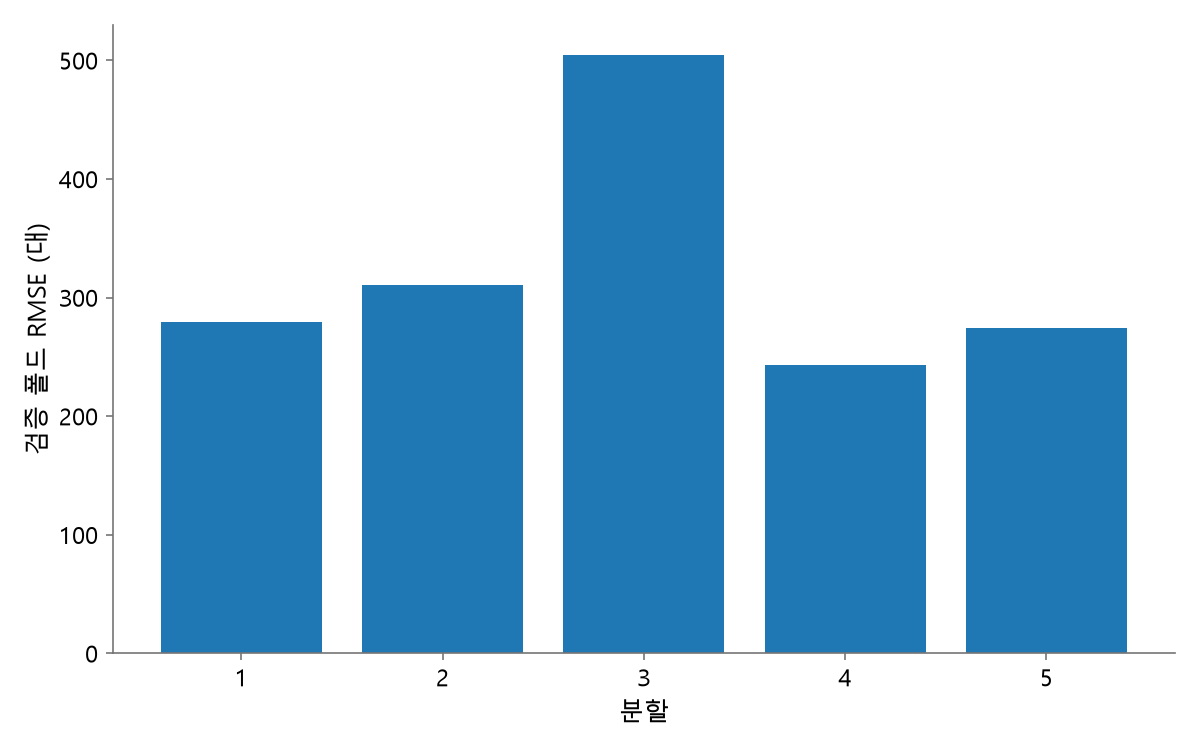

In [12]:
# 미션 2 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → AI 튜터에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
# 시킬 일은 AI 튜터 대화창이 아니라 아래 따옴표 안에 적습니다. 따옴표 안이 비어 있으면 채점과 완성본 풀이가 잠깁니다
PROMPT = """
아래 출력물 나오게 코드 작성해줘
1. ridge regression 5분할 평균 RMSE: 단위 '대', 소수 둘째자리
2. 분할 1 스케일러 기온 평균: 단위 섭씨 기호, 소수 둘째자리
3. 그래프
가로축: '분할' 1~5
세로축: '검증 폴드 RMSE (대)'인 막대 그래프 5개

"""
# --- 여기부터 AI 코드 ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

tscv = TimeSeriesSplit(n_splits=5, test_size=168)

rmses = []
split1_temp_mean = None

for i, (train_idx, test_idx) in enumerate(tscv.split(X_cv)):
    X_train, X_test = X_cv[train_idx], X_cv[test_idx]
    y_train, y_test = y_cv[train_idx], y_cv[test_idx]

    pipe = make_pipeline(StandardScaler(), Ridge(alpha=100))
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    fold_rmse = mean_squared_error(y_test, y_pred) ** 0.5
    rmses.append(fold_rmse)

    if i == 0:
        scaler = pipe.named_steps['standardscaler']
        split1_temp_mean = scaler.mean_[TEMP_COL]

print(f"릿지 5분할 평균 RMSE = {np.mean(rmses):.2f}대")
print(f"분할 1 스케일러 기온 평균 = {split1_temp_mean:.2f}°C")

plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), rmses)
plt.xlabel('분할')
plt.ylabel('검증 폴드 RMSE (대)')
plt.xticks(range(1, 6))
plt.show()

분할 1 스케일러의 기온 평균은 전체 2,016시간의 평균과 비교해 어떨까요?

1더 높다. 분할 1 의 학습 폴드에 추운 11월이 없다

▸
예측 원점 5개 평균 RMSE: 셋째 날 SARIMA 약 385대, 둘째 날 ARIMA 약 426대, 계절 나이브 168 363.55대. 11월 16일 한 주에서는 둘째 날 ARIMA 가 더 작았지만, 원점 5개 평균에서는 순위가 반대입니다
▸
교차 검증 값은 TimeSeriesSplit(n_splits=5, test_size=168) 로 나누고 스케일러를 분할마다 학습 폴드로만 fit 한 값만 보고합니다. 분할 1 의 스케일러 기온 평균은 18.79 °C 로, 11월까지 포함한 전체 평균 14.92 °C 와 다릅니다
▸
할 일: 운영 예측은 계절 나이브 168 로 냅니다. 코드는 df["demand"].shift(168) 한 행입니다. 평가표에는 원점 5개별 RMSE 와 평균, 학습 구간(9월 1일부터 원점까지), 예측 기간 168시간을 함께 적습니다